In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.skills_processing import create_skills_df

df = pd.read_pickle("../data/processed/cleaned_jobs.pkl")

skills_df = create_skills_df(df)

In [2]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",[Work Nearby],Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,[],{},J-e02c886264ce
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[nosql, power bi, python, r, sql, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",[LinkedIn],Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[airflow, azure, c#, dax, docker, jenkins, kub...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",J-c8afb754b830
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",[Diversity.com],Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[aws, c++, java, keras, matlab, python, pytorc...","{'cloud': ['aws'], 'libraries': ['keras', 'pyt...",J-6b595ba75824
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",[Clearance Jobs],Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[ansible, aws, bash, git, gitlab, jenkins, ora...","{'cloud': ['aws', 'oracle'], 'other': ['ansibl...",J-88bb30c3cf7d


In [3]:
skills_df.head()

,job_id,job_title_short,category,skill
1,J-64833455be38,Data Analyst,analyst_tools,power bi
1,J-64833455be38,Data Analyst,analyst_tools,tableau
1,J-64833455be38,Data Analyst,programming,nosql
1,J-64833455be38,Data Analyst,programming,python
1,J-64833455be38,Data Analyst,programming,r


In [4]:
# skill demand (how often skill appears)
skill_demand = skills_df['skill'].value_counts().rename('count')

# merge salary
skill_salary = (
    skills_df.merge(df[['job_id', 'salary_year_avg']], on='job_id')
    .groupby('skill')['salary_year_avg']
    .median()
    .rename('median_salary')
)

# combine
skill_plot_df = pd.concat([skill_demand, skill_salary], axis=1).dropna()

# optional: filter top skills
skill_plot_df = skill_plot_df[skill_plot_df['count'] > 50]

skill_category = skills_df[['skill', 'category']].drop_duplicates()

total_jobs = skills_df['job_id'].nunique()

# merge
skill_plot_df = skill_plot_df.reset_index().merge(skill_category, on='skill', how='left')

skill_plot_df['demand_pct'] = (skill_plot_df['count'] / total_jobs) * 100

In [5]:
skill_plot_df

,skill,count,median_salary,category,demand_pct
0,sql,384537,120000.0,programming,57.562489
1,python,380602,125000.0,programming,56.973447
2,aws,145304,135000.0,cloud,21.750989
3,azure,132469,125000.0,cloud,19.829679
4,r,130834,119550.0,programming,19.584931
...,...,...,...,...,...
211,lisp,75,100000.0,programming,0.011227
212,wrike,73,101250.0,async,0.010928
213,pascal,68,92000.0,programming,0.010179
214,blazor,67,56700.0,webframeworks,0.010029


In [6]:
skill_plot_df = skill_plot_df.head(10)
skill_plot_df

,skill,count,median_salary,category,demand_pct
0,sql,384537,120000.0,programming,57.562489
1,python,380602,125000.0,programming,56.973447
2,aws,145304,135000.0,cloud,21.750989
3,azure,132469,125000.0,cloud,19.829679
4,r,130834,119550.0,programming,19.584931
5,tableau,127157,111175.0,analyst_tools,19.034510
6,excel,126956,92500.0,analyst_tools,19.004422
7,spark,114547,140000.0,libraries,17.146882
8,power bi,98102,102000.0,analyst_tools,14.685181
9,java,85557,134241.0,programming,12.807282


In [7]:
role_salary = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=False)

In [8]:
role_salary

job_title_short
Senior Data Scientist        154206.292996
Senior Data Engineer         145840.611624
Data Scientist               135992.381984
Data Engineer                130125.604250
Machine Learning Engineer    126774.315972
Senior Data Analyst          113911.363665
Software Engineer            113393.760054
Cloud Engineer               111268.453846
Data Analyst                  93837.359753
Business Analyst              91082.612833
Name: salary_year_avg, dtype: float64

In [9]:
high_roles = role_salary.head(5).index
low_roles = role_salary.tail(5).index

In [10]:
high_skills = skills_df[skills_df['job_title_short'].isin(high_roles)]
high_skills

,job_id,job_title_short,category,skill
2,J-c8afb754b830,Data Engineer,analyst_tools,dax
2,J-c8afb754b830,Data Engineer,cloud,azure
2,J-c8afb754b830,Data Engineer,libraries,airflow
2,J-c8afb754b830,Data Engineer,other,docker
2,J-c8afb754b830,Data Engineer,other,jenkins
...,...,...,...,...
785739,J-a94d273e8878,Data Engineer,programming,mongo
785739,J-a94d273e8878,Data Engineer,programming,nosql
785739,J-a94d273e8878,Data Engineer,programming,python
785739,J-a94d273e8878,Data Engineer,programming,shell


In [11]:
low_skills = skills_df[skills_df['job_title_short'].isin(low_roles)]
low_skills

,job_id,job_title_short,category,skill
1,J-64833455be38,Data Analyst,analyst_tools,power bi
1,J-64833455be38,Data Analyst,analyst_tools,tableau
1,J-64833455be38,Data Analyst,programming,nosql
1,J-64833455be38,Data Analyst,programming,python
1,J-64833455be38,Data Analyst,programming,r
...,...,...,...,...
785737,J-8fc5a53a787e,Data Analyst,programming,sql
785738,J-03cf31bd4b96,Business Analyst,analyst_tools,excel
785738,J-03cf31bd4b96,Business Analyst,analyst_tools,powerpoint
785740,J-03b27285205d,Software Engineer,cloud,aws


In [12]:
high_skill_counts = high_skills['skill'].value_counts().head(10)
low_skill_counts = low_skills['skill'].value_counts().head(10)

In [13]:
skills_compare = pd.DataFrame({
    'High Paying Roles': high_skill_counts,
    'Low Paying Roles': low_skill_counts
}).fillna(0)
skills_compare['diff'] = (
    skills_compare['High Paying Roles'] - skills_compare['Low Paying Roles']
)

skills_compare = skills_compare.sort_values(by='diff', ascending=False)
skills_compare

,High Paying Roles,Low Paying Roles,diff
skill,,,
python,285965.0,94637.0,191328.0
spark,103260.0,0.0,103260.0
sql,242600.0,141937.0,100663.0
aws,118807.0,26497.0,92310.0
azure,106716.0,25753.0,80963.0
java,67379.0,0.0,67379.0
hadoop,56869.0,0.0,56869.0
scala,51673.0,0.0,51673.0
r,88986.0,41848.0,47138.0


In [14]:
top10_skills = skill_plot_df['skill'].tolist()
top10_skills

['sql',
 'python',
 'aws',
 'azure',
 'r',
 'tableau',
 'excel',
 'spark',
 'power bi',
 'java']

In [15]:
skills_compare = skills_compare.loc[top10_skills]
skills_compare

,High Paying Roles,Low Paying Roles,diff
skill,,,
sql,242600.0,141937.0,100663.0
python,285965.0,94637.0,191328.0
aws,118807.0,26497.0,92310.0
azure,106716.0,25753.0,80963.0
r,88986.0,41848.0,47138.0
tableau,59235.0,67922.0,-8687.0
excel,0.0,95589.0,-95589.0
spark,103260.0,0.0,103260.0
power bi,0.0,56373.0,-56373.0


In [16]:
skills_compare = skills_compare.sort_values(
    by='High Paying Roles', ascending=False
)
skills_compare

,High Paying Roles,Low Paying Roles,diff
skill,,,
python,285965.0,94637.0,191328.0
sql,242600.0,141937.0,100663.0
aws,118807.0,26497.0,92310.0
azure,106716.0,25753.0,80963.0
spark,103260.0,0.0,103260.0
r,88986.0,41848.0,47138.0
java,67379.0,0.0,67379.0
tableau,59235.0,67922.0,-8687.0
excel,0.0,95589.0,-95589.0


In [17]:
skills_compare['diff_pct'] = (
    skills_compare['High Paying Roles'] /
    (skills_compare['High Paying Roles'] + skills_compare['Low Paying Roles'])
)
skills_compare

,High Paying Roles,Low Paying Roles,diff,diff_pct
skill,,,,
python,285965.0,94637.0,191328.0,0.751349
sql,242600.0,141937.0,100663.0,0.630889
aws,118807.0,26497.0,92310.0,0.817644
azure,106716.0,25753.0,80963.0,0.805592
spark,103260.0,0.0,103260.0,1.000000
r,88986.0,41848.0,47138.0,0.680144
java,67379.0,0.0,67379.0,1.000000
tableau,59235.0,67922.0,-8687.0,0.465841
excel,0.0,95589.0,-95589.0,0.000000


In [18]:
skills_pct = skills_compare[['High Paying Roles', 'Low Paying Roles']].div(
    skills_compare[['High Paying Roles', 'Low Paying Roles']].sum(axis=1),
    axis=0
)

labels = [
    f"{skill}\n({diff:.2f})"
    for skill, diff in zip(skills_compare.index, skills_compare['diff'])
]

#skills_pct.index = labels
skills_pct.index = skills_compare.index

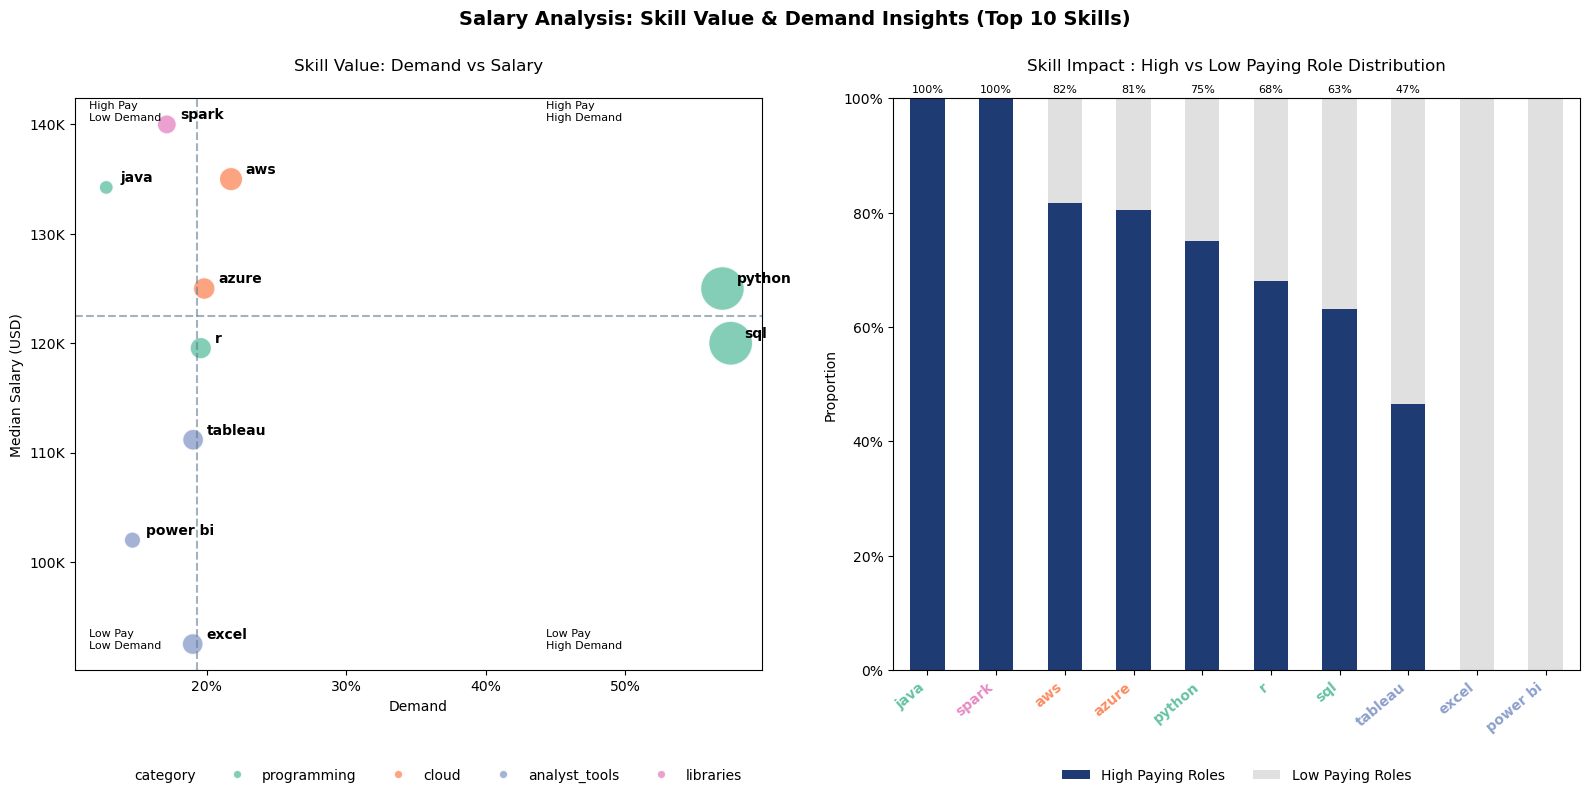

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

fig.suptitle(
    'Salary Analysis: Skill Value & Demand Insights (Top 10 Skills)',
    fontsize=14,
    weight='bold',
    y=1
)

skills_pct = skills_pct.loc[
    skills_compare['diff_pct'].sort_values(ascending=False).index
]

sns.scatterplot(
    data=skill_plot_df,
    x='demand_pct',
    y='median_salary',
    hue='category',
    size='count',
    sizes=(100, 1000),
    alpha=0.8,
    palette='Set2',
    ax=axes[0]
)

# labels
for _, row in skill_plot_df.iterrows():
    axes[0].text(
        row['demand_pct'] + 1,
        row['median_salary'] + 500,
        row['skill'],
        fontsize=10,
        weight='bold'
    )

axes[0].set_title('Skill Value: Demand vs Salary',pad=20)
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Median Salary (USD)')
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{int(y/1000)}K')
)
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x)}%')
)

axes[0].axvline(skill_plot_df['demand_pct'].median(), linestyle='--', alpha=0.3)
axes[0].axhline(skill_plot_df['median_salary'].median(), linestyle='--', alpha=0.3)

ax = axes[0]

# --- Median lines ---
x_mid = skill_plot_df['demand_pct'].median()
y_mid = skill_plot_df['median_salary'].median()

ax.axvline(x_mid, linestyle='--', alpha=0.4, color='gray')
ax.axhline(y_mid, linestyle='--', alpha=0.4, color='gray')


# --- Get axis limits ---
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()


# --- Quadrant labels (dynamic, no hardcoding) ---
ax.text(x_min + 1, y_max - 2000, 'High Pay\nLow Demand', fontsize=8)
ax.text(x_mid + 25, y_max - 2000, 'High Pay\nHigh Demand', fontsize=8)

ax.text(x_min + 1, y_min + 2000, 'Low Pay\nLow Demand', fontsize=8)
ax.text(x_mid + 25, y_min + 2000, 'Low Pay\nHigh Demand', fontsize=8)

handles, labels = axes[0].get_legend_handles_labels()

# Keep only category labels (remove numeric size labels)
filtered = [(h, l) for h, l in zip(handles, labels) 
            if l not in ['count'] and not l.isdigit()]

handles, labels = zip(*filtered)

axes[0].legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),  # below chart
    ncol=5,
    frameon=False
)

skills_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#1f3b73', '#e0e0e0'] 
)

# for i, val in enumerate(skills_compare['diff_pct']):
#     axes[1].text(i, 1.01, f"{val:.0%}", ha='center', fontsize=8)

for i, val in enumerate(skills_pct['High Paying Roles']):
    label = f"{val:.0%}" if val > 0 else ""

    axes[1].text(
        i,
        1.01,
        label,
        ha='center',
        fontsize=8
    )

axes[1].set_title('Skill Impact : High vs Low Paying Role Distribution',pad=20)
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{int(y*100)}%')
)
axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=40,
    ha='right'
)

palette = sns.color_palette('Set2', n_colors=skill_plot_df['category'].nunique())
categories = skill_plot_df['category'].unique()

color_map = dict(zip(categories, palette))

skill_color_map = dict(
    zip(skill_plot_df['skill'], skill_plot_df['category'].map(color_map))
)

for label in axes[1].get_xticklabels():
    skill = label.get_text()
    if skill in skill_color_map:
        label.set_color(skill_color_map[skill])
        label.set_fontweight('bold')

axes[1].legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

In [20]:
#Salary by Experience Level
#sns.barplot(data=df, x='experience_level', y='salary', hue='job_title_short')

In [21]:
top_roles = df['job_title_short'].value_counts().head(3).index
top_roles

Index(['Data Analyst', 'Data Engineer', 'Data Scientist'], dtype='str', name='job_title_short')

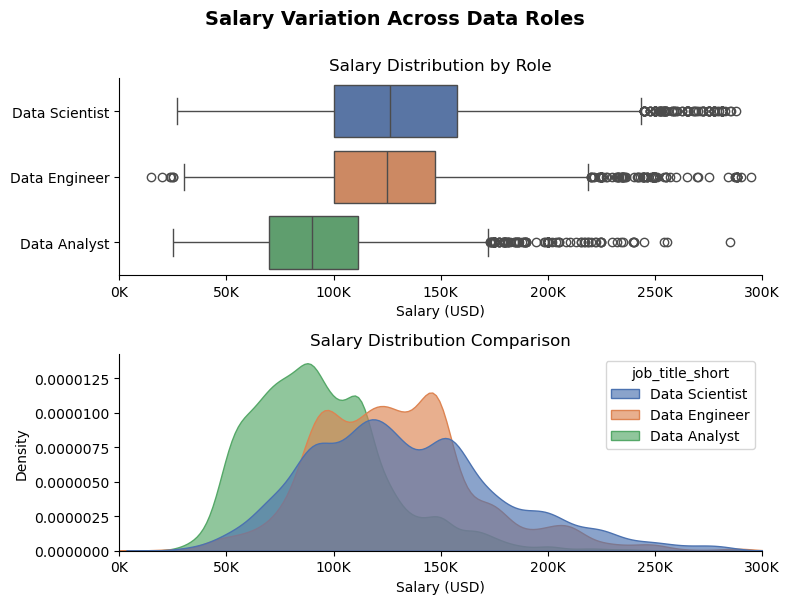

In [22]:
df_salary = df[df['salary_year_avg'] < 300000]
df_plot = df_salary[df_salary['job_title_short'].isin(top_roles)]

# --- ORDER (important for consistency) ---
order = (
    df_plot.groupby('job_title_short')['salary_year_avg']
    .median()
    .sort_values(ascending=False)
    .index
)

# --- FIGURE ---
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

fig.suptitle(
    'Salary Variation Across Data Roles',
    fontsize=14,
    weight='bold',
    y=1
)

palette = {
    "Data Scientist": "#4C72B0",  # blue
    "Data Engineer": "#DD8452",   # orange
    "Data Analyst": "#55A868"     # green
}

xmin, xmax = 0, 300000

# =======================
# 1. BOXPLOT (TOP)
# =======================
sns.boxplot(
    data=df_plot,
    y='job_title_short',
    x='salary_year_avg',
    order=order,
    hue='job_title_short',   # 👈 add this
    palette=palette,
    dodge=False,             # 👈 important (prevents split boxes)
    legend=False, 
    ax=axes[0]
)

axes[0].set_title('Salary Distribution by Role')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(lambda x, _: f'{int(x/1000)}K')
axes[0].set_xlim(xmin, xmax)


# =======================
# 2. KDE (BOTTOM)
# =======================
sns.kdeplot(
    data=df_plot,
    x='salary_year_avg',
    hue='job_title_short',
    palette=palette,
    common_norm=False,
    fill=True,
    alpha=0.65,
    ax=axes[1]
)

axes[1].set_title('Salary Distribution Comparison')
axes[1].set_xlabel('Salary (USD)')
axes[1].set_ylabel('Density')
axes[1].xaxis.set_major_formatter(lambda x, _: f'{int(x/1000)}K')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].set_xlim(xmin, xmax)


# --- CLEANUP ---
sns.despine()
plt.tight_layout()

plt.show()

In [23]:
# “Density shows the relative concentration of salaries across ranges, normalized so distributions can be compared regardless of sample size.”

In [24]:
top_roles = df['job_title_short'].value_counts().head(3).index
top_countries = df['job_country'].value_counts().head(6).index

df_job_country_salary = df.pivot_table(
    values='salary_year_avg',
    index='job_title_short',
    columns='job_country',
    aggfunc='median'
    )

df_job_country_salary = df_job_country_salary.loc[top_roles] #.loc since roles are index

#job_titles = ['Data Analyst','Data Engineer','Data Scientist']

df_job_country_salary = df_job_country_salary[top_countries] #since countries are columns so no need for loc
df_job_country_salary

job_country,United States,India,United Kingdom,France,Germany,Spain
job_title_short,,,,,,
Data Analyst,90000.0,100500.0,87750.0,69175.0,103750.0,91977.0
Data Engineer,125000.0,147500.0,110000.0,98301.5,147500.0,133000.0
Data Scientist,130000.0,114008.0,105300.0,88128.0,131560.0,88128.0


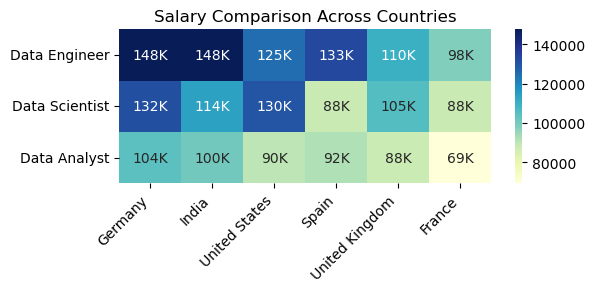

In [25]:
role_order = df_job_country_salary.mean(axis=1).sort_values(ascending=False).index
df_job_country_salary = df_job_country_salary.loc[role_order]

country_order = df_job_country_salary.mean(axis=0).sort_values(ascending=False).index
df_job_country_salary = df_job_country_salary[country_order]

plt.figure(figsize=(6,2))

annot_labels = df_job_country_salary.map(lambda x: f"{round(x/1000)}K")

sns.heatmap(
    df_job_country_salary,
    annot=annot_labels,
    #fmt=",.0f",
    fmt="",
    cmap="YlGnBu"
)

plt.title('Salary Comparison Across Countries')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45,ha='right')

plt.show()